# Week 1: System exploration (Group)

In the first stage, your aim is to **understand the behaviour of a system**.

You should focus on questions like:

- How do the observed signals change over time?
- How do different input patterns affect the observations?
- Are some signals more informative than others?
- What is easy to observe, and what seems hidden?

At this stage, the priority is **exploration and intuition-building**, not solving the whole project.

## Group tasks for Week 1

As a group, extend the basic experiment and **build a shared code workflow.**

Your group should aim to produce:

- a clean way to explore dataset, either from simulation or experiment,
- standard plotting functions,
- a simulation platform for studying and comparing effects of different input patterns and system dynamics (transition matrices), for example:
  - random inputs,
  - pulses,
  - oscillatory inputs,
  - activating only one input channel at a time,
  - activating different channels with different amplitudes,
  - exploring the relationship between input structure and system dynamics (such as coupling between inputs and transition matrices);
- brief documentation so that all group members can build on the same starting point.

All of the above tasks should be completed by Friday 22 May, before the scheduled check-in session.

## Week 1 deliverable

**Deliverable:** Group simulation code + brief documentation  
**Marks:** 10 group marks  
**Due:** Friday 22 May, 11am–1pm (**compulsory session**)

At the check-in session, the demonstrator will review the code and ask each member of the group questions about it. Every member of the group is therefore expected to have contributed to the code and to take full responsibility for understanding it.


## Example dataset


In [1]:
# loading dataset
import numpy as np

data = np.load("ExampleDataset.npy")
print(
    "Dataset loaded successfully. Shape:", data.shape
)  # (Trials, Timepoints, Neurons)

Dataset loaded successfully. Shape: (5, 60, 16)


## Desgin an illustrator

A class that can generate primary statistics, analyses, and visualization of any dataset. Design your illustrator in **Illustrator.py**.

To test your documentation, the demonstrator will use your illustrator here, but will never see your code (in this section).

Please make your annotations clear and comprehensive!


Dataset summary
  Shape      : (5, 60, 16)  (n_trials=5, n_timesteps=60, n_neurons=16)

  Neuron             Mean      SEM      Min      Max
  ------------------------------------------------
  Neuron 0          3.292    0.000   -1.793    9.791
  Neuron 1          3.233    0.000   -0.883    9.424
  Neuron 2          3.404    0.000   -2.127    9.832
  Neuron 3          2.293    0.000   -1.580    6.911
  Neuron 4          3.500    0.000   -3.000    9.746
  Neuron 5          3.345    0.000   -0.454   10.161
  Neuron 6          3.412    0.000   -1.363   11.194
  Neuron 7          2.246    0.000   -2.275    6.743
  Neuron 8          3.329    0.000   -1.569   10.299
  Neuron 9          3.580    0.000   -1.381   10.671
  Neuron 10         3.209    0.000   -1.002   10.733
  Neuron 11         3.203    0.000   -2.088   10.256
  Neuron 12         3.430    0.000   -1.448    9.625
  Neuron 13         3.601    0.000   -1.351   10.517
  Neuron 14         3.731    0.000   -1.452   10.246
  Neuron 15  

{'trials': <Figure size 1000x2000 with 5 Axes>,
 'trial_average': <Figure size 1000x400 with 1 Axes>,
 'neuron_time_heatmap': <Figure size 800x500 with 2 Axes>,
 'trial_heatmaps': <Figure size 1000x2000 with 10 Axes>,
 'correlation': <Figure size 600x500 with 2 Axes>,
 'pca': <Figure size 1200x400 with 3 Axes>,
 'variance_explained': <Figure size 600x400 with 2 Axes>,
 'autocorrelation': <Figure size 1000x400 with 1 Axes>,
 'cross_correlation': <Figure size 1000x400 with 1 Axes>,
 'power_spectrum': <Figure size 1000x400 with 1 Axes>,
 'coherence': <Figure size 1000x400 with 1 Axes>,
 'coherence_matrix': <Figure size 600x500 with 2 Axes>}

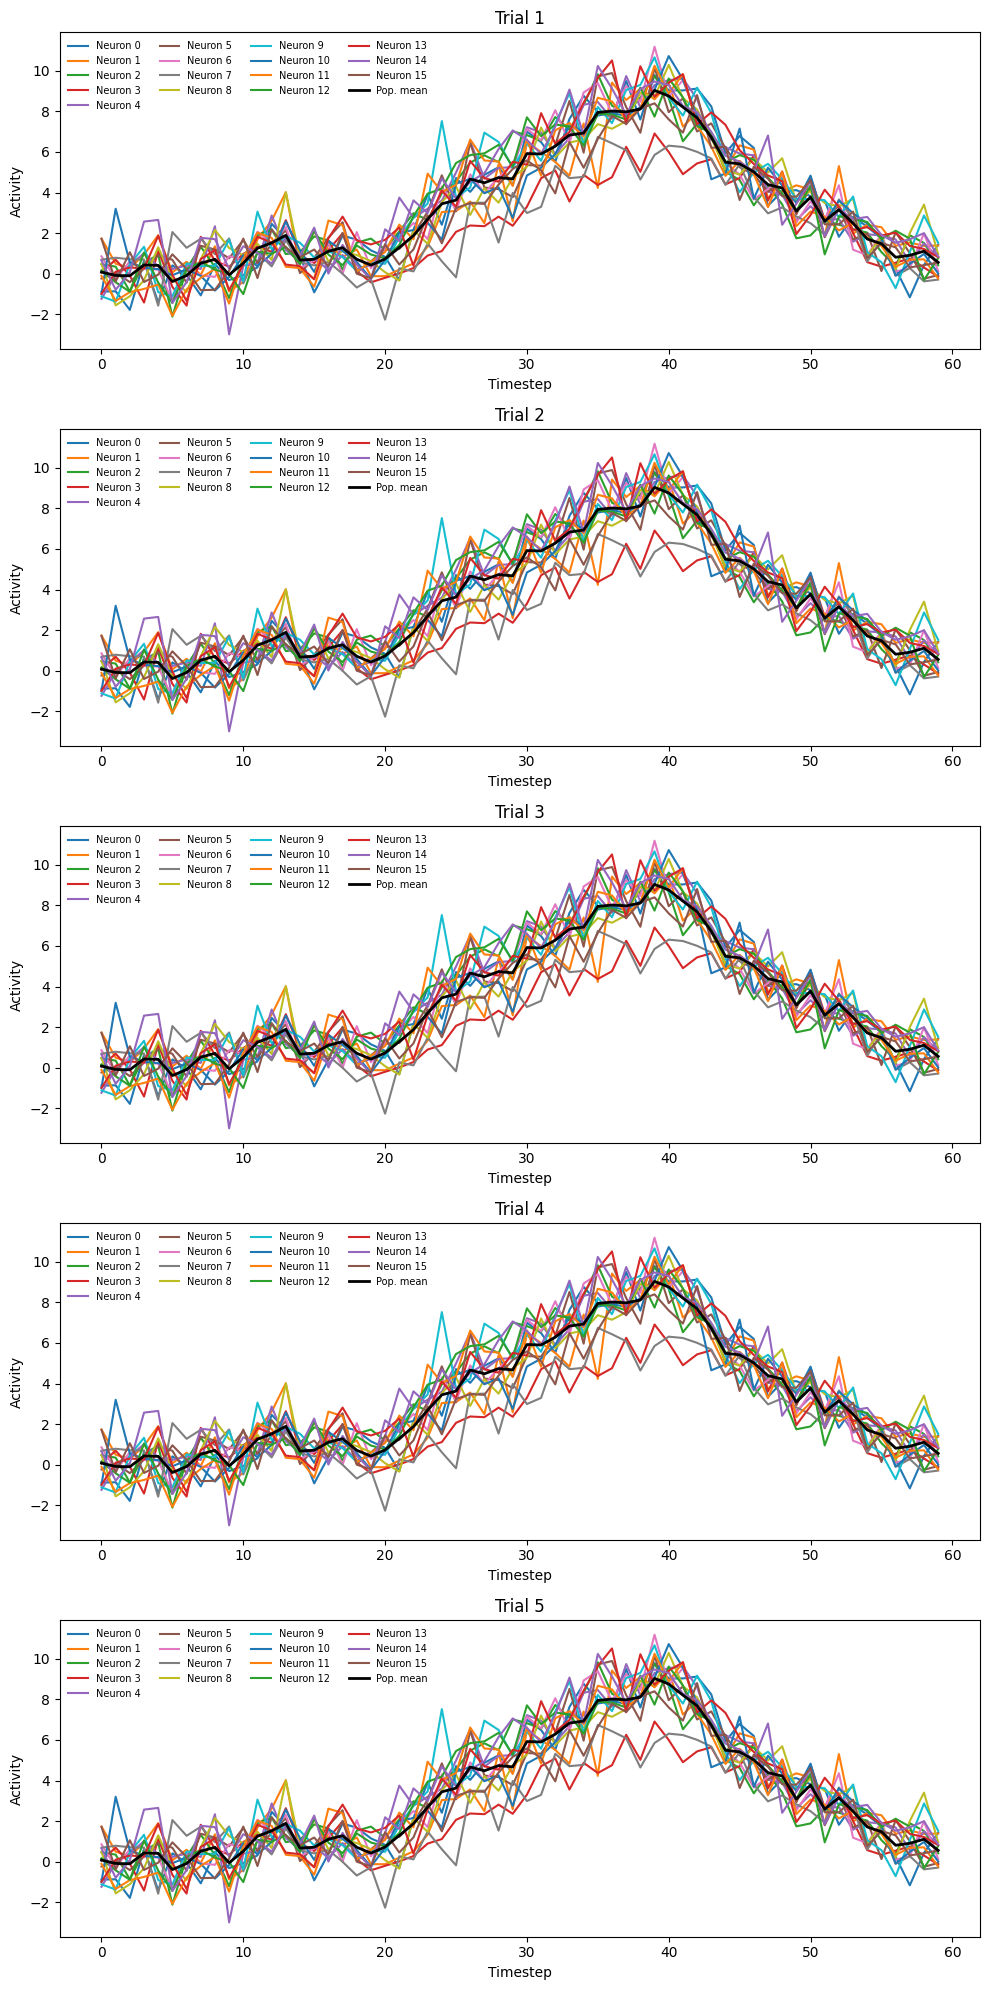

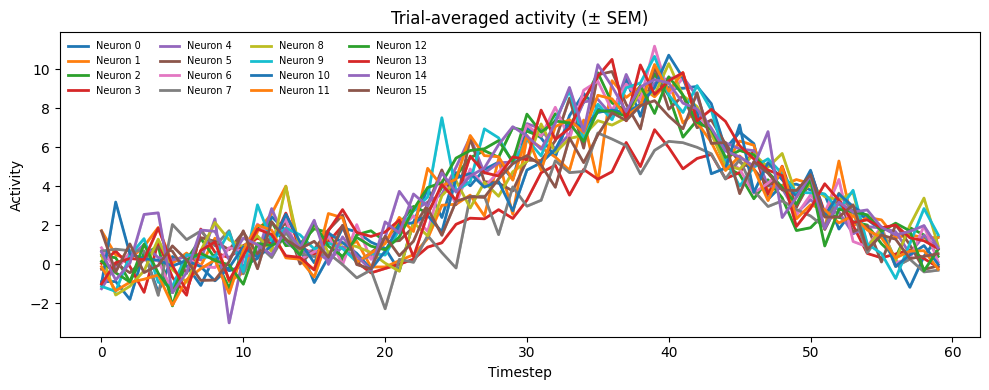

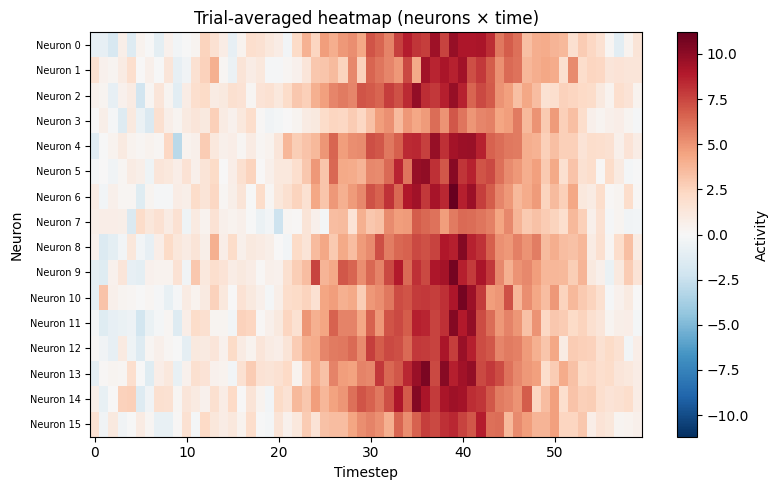

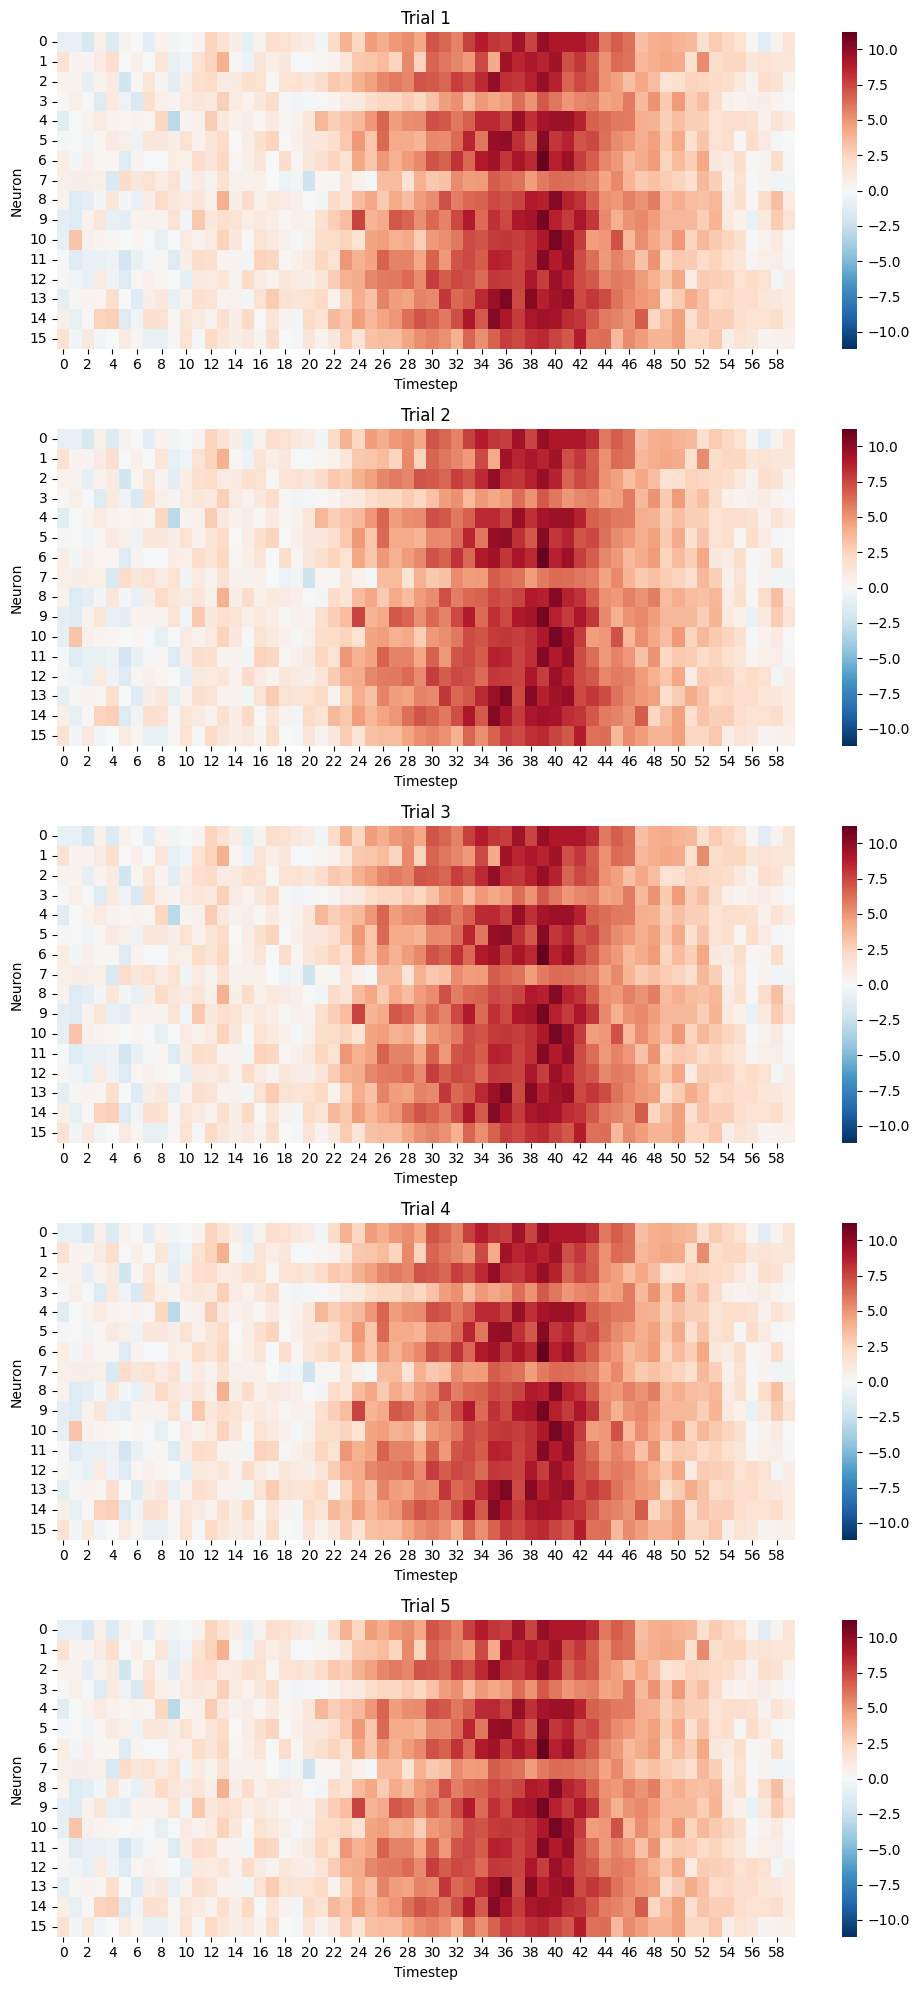

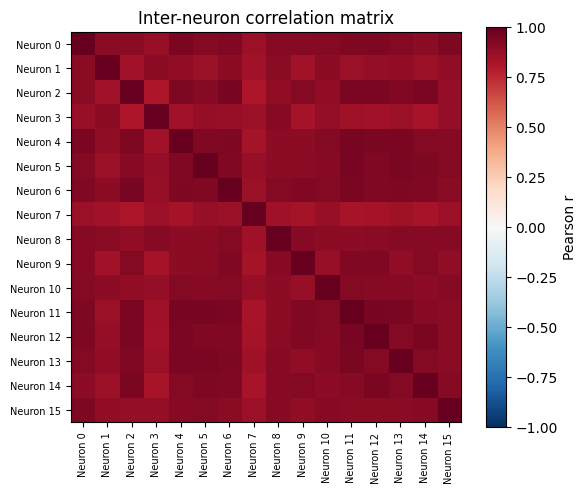

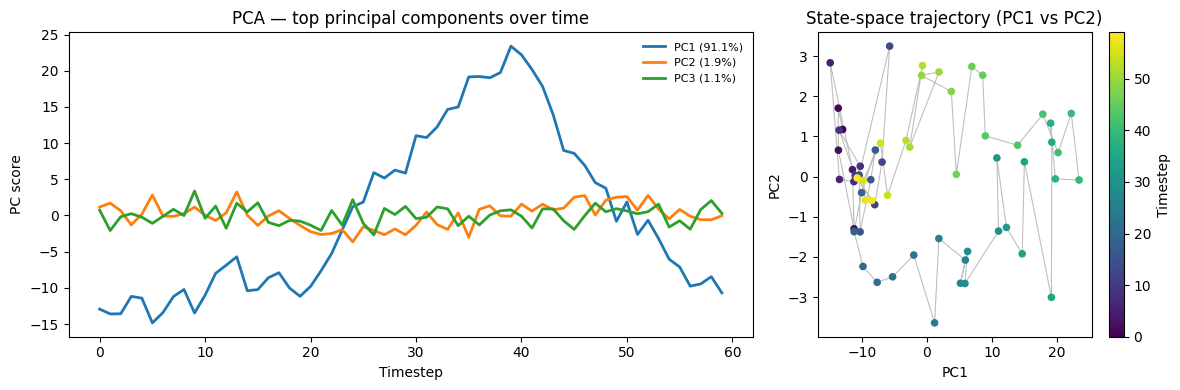

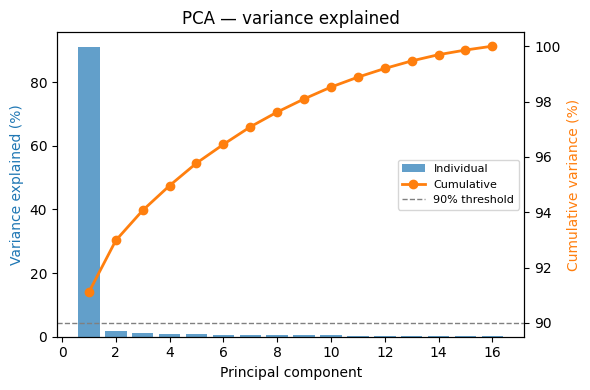

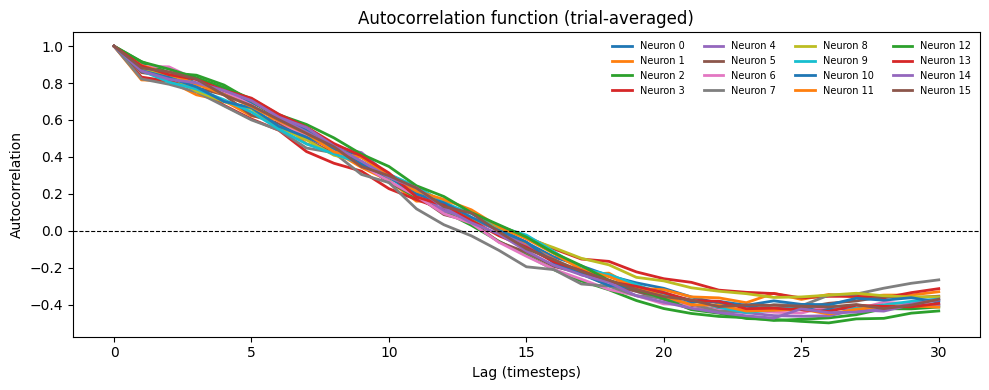

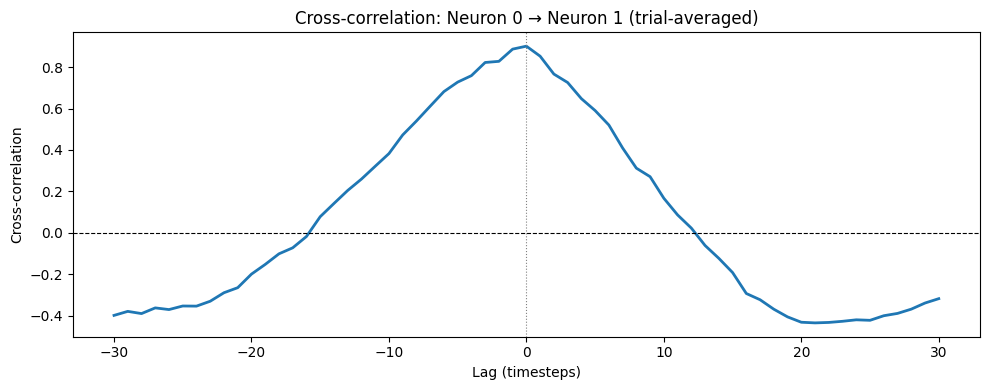

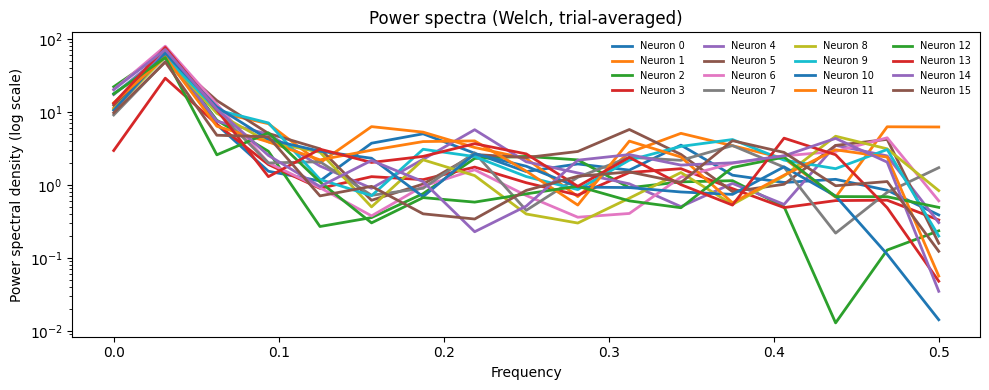

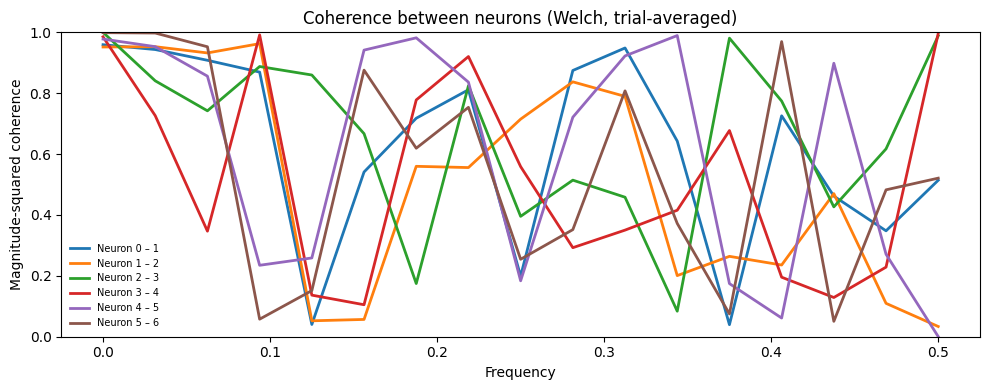

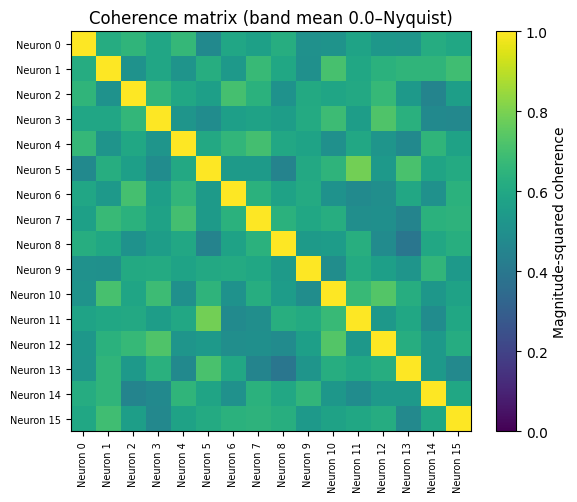

In [2]:
from l4b.illustrator import Illustrator

illustrator = Illustrator(data)
illustrator.plot_all()

## Design a simulator

In GG4, we use a simple linear model:

$$
x_{t+1} = Ax_t + Bu_t + w_t, w_t \sim \mathcal{N}(0, Q)
$$

$$
y_t = Cx_t + o_t, o_t \sim \mathcal{N}(0, R)
$$

Your simulator should be able to simulate observation of any length given different parameters.

Design your simulator in **Simulator.py**.

To test your documentation, the demonstrator will use your simulator here, but will never see your code (in this section).
Please make your annotations clear and comprehensive!

Combining the illustrator and simulator, what's your findings? Illustrate them.
This forms your answer to the question: "effects of different input patterns and system dynamics"


States:       (10, 100, 2)  # (trials, timesteps, state_dim)
Observations: (10, 100, 2)  # (trials, timesteps, obs_dim)


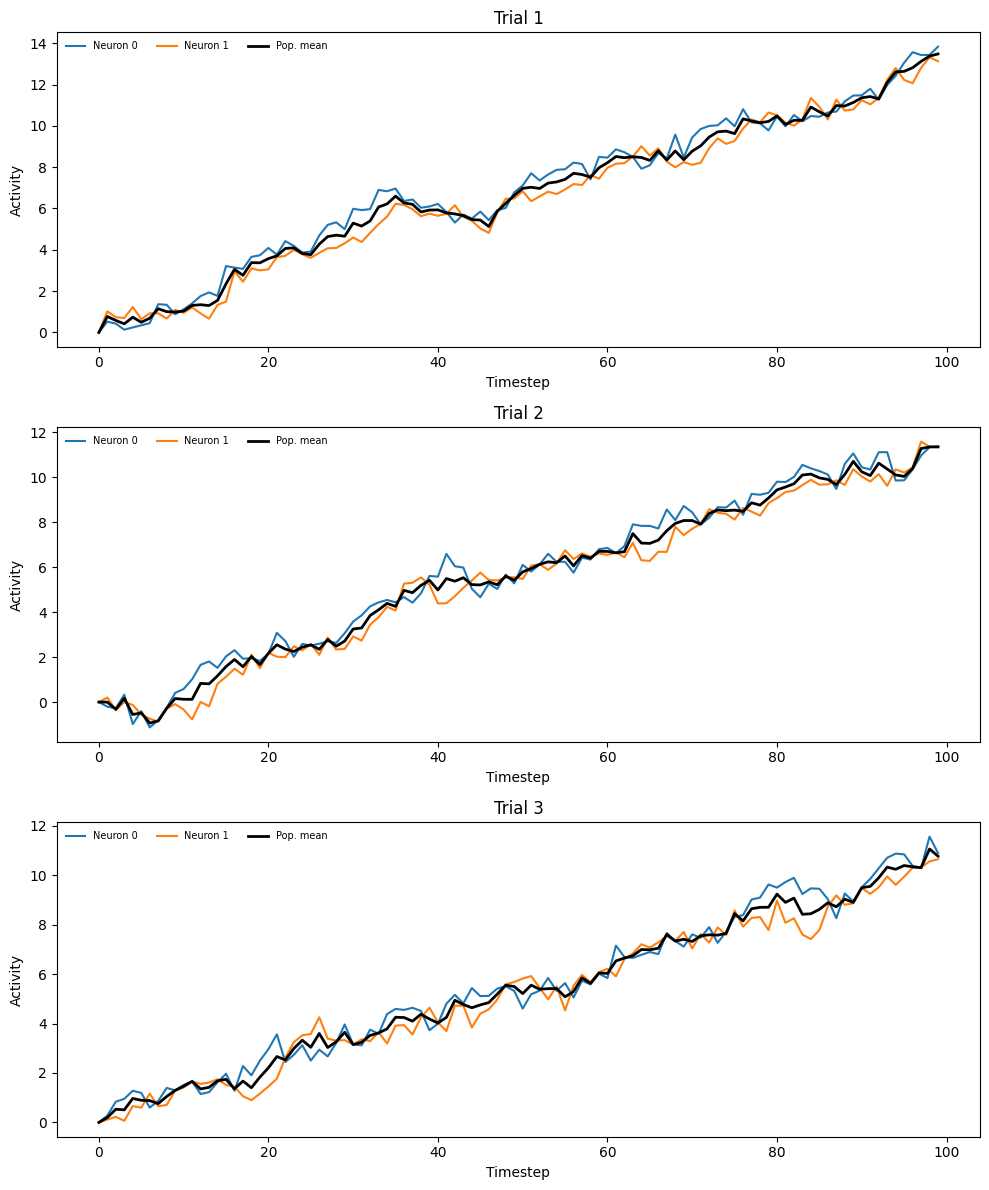

In [ ]:
from l4b.simulator import Simulator
import numpy as np

# Corrected minimal example: 2 latent states, 1 input, 2 observed neurons
T = 100
model = {
    "state_dim": 2,
    "input_dim": 1,
    "obs_dim": 2,
    "A": np.array([[0.9, 0.1], [0.2, 0.8]]),
    "B": np.array([[0.5], [0.2]]),
    "C": np.eye(2),  # observe both latent states
    "Q": np.eye(2) * 0.1,  # isotropic process noise
    "R": np.eye(2) * 0.05,  # isotropic observation noise
}

sim = Simulator(model)
u = np.ones((T, 1)) * 0.3  # constant input, shape (time_steps, input_dim)
states, observations = sim.run(
    initial_state=np.zeros(2),  # shape (state_dim,)
    control_inputs=u,
    time_steps=T,
    trials=10,
)
print(f"States:       {states.shape}  # (trials, timesteps, state_dim)")
print(f"Observations: {observations.shape}  # (trials, timesteps, obs_dim)")

from l4b.illustrator import Illustrator

fig = Illustrator(observations).plot_trials(trials=[0, 1, 2])

## Input pattern comparison

We hold the model $(A, B, C, Q, R)$ fixed and vary only the input signal $u_t$ to isolate how each driving pattern shapes the observations.

Patterns studied:

- **Zero input** — baseline free decay; any activity reflects initial conditions and noise only.
- **Constant step** — sustained driving; reveals the steady-state gain $B(I-A)^{-1}$.
- **Pulse** — brief activation; traces the system's _impulse response_, shaped entirely by $A$.
- **Oscillatory (slow / fast)** — reveals frequency-selective filtering: $A$ attenuates inputs faster than its dominant time constant.


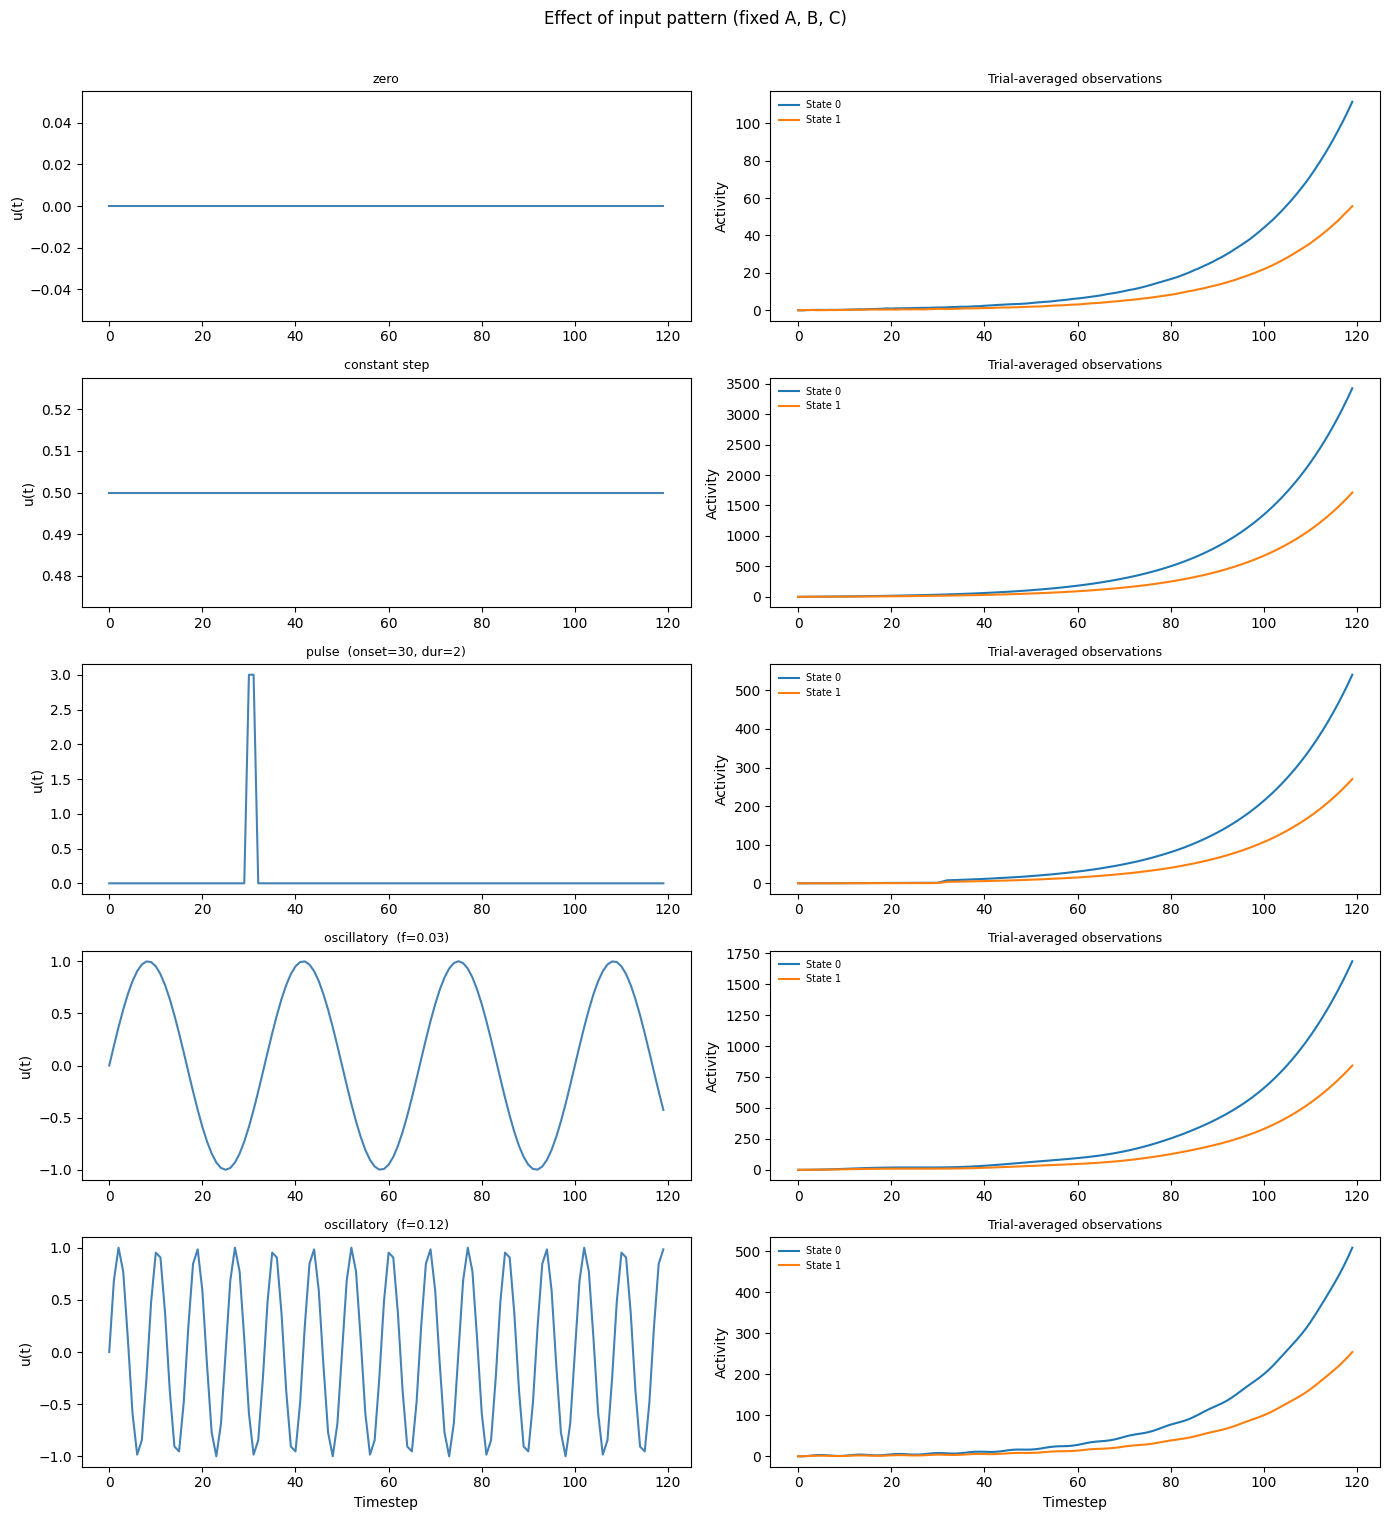

In [ ]:
from l4b.inputs import zero, pulse, oscillatory
from l4b.simulator import Simulator
import matplotlib.pyplot as plt
import numpy as np

T, n_trials = 120, 30
state_dim, input_dim, obs_dim = 2, 1, 2

ref_model = {
    "state_dim": state_dim,
    "input_dim": input_dim,
    "obs_dim": obs_dim,
    "A": np.array([[0.9, 0.3], [0.1, 0.85]]),
    "B": np.array([[1.0], [0.5]]),
    "C": np.eye(obs_dim),
    "Q": np.eye(state_dim) * 0.05,
    "R": np.eye(obs_dim) * 0.02,
    "seed": 0,
}

conditions = {
    "zero": zero(T, input_dim),
    "constant step": np.ones((T, input_dim)) * 0.5,
    "pulse  (onset=30, dur=2)": pulse(
        T, input_dim, onset=30, duration=2, amplitude=3.0
    ),
    "oscillatory  (f=0.03)": oscillatory(T, input_dim, freq=0.03),
    "oscillatory  (f=0.12)": oscillatory(T, input_dim, freq=0.12),
}

fig, axes = plt.subplots(len(conditions), 2, figsize=(14, 3 * len(conditions)))

for row, (label, u) in enumerate(conditions.items()):
    _, obs = Simulator(ref_model).run(
        initial_state=np.zeros(state_dim),
        control_inputs=u,
        time_steps=T,
        trials=n_trials,
    )
    mean_obs = obs.mean(axis=0)

    axes[row, 0].plot(u[:, 0], color="steelblue")
    axes[row, 0].set_title(label, fontsize=9)
    axes[row, 0].set_ylabel("u(t)")

    for k in range(obs_dim):
        axes[row, 1].plot(mean_obs[:, k], label=f"State {k}")
    axes[row, 1].set_title("Trial-averaged observations", fontsize=9)
    axes[row, 1].set_ylabel("Activity")
    axes[row, 1].legend(fontsize=7, frameon=False)

for ax in axes[-1]:
    ax.set_xlabel("Timestep")

fig.suptitle("Effect of input pattern (fixed A, B, C)", y=1.01)
fig.tight_layout()
plt.show()

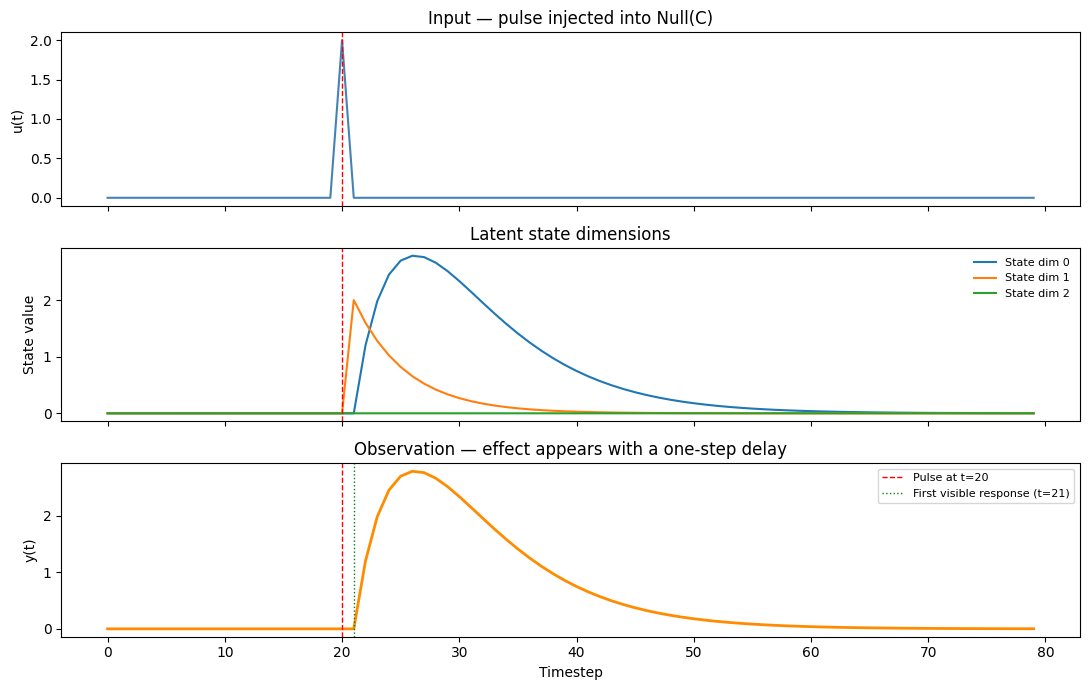

y(t=20  ) = 0.0000   ← input in Null(C), invisible at injection
y(t=21) = 0.0000   ← propagated through A in one step
y(t=22) = 1.2000   ← decaying via eigenvalues of A


In [ ]:
from l4b.simulator import Simulator
from l4b.inputs import pulse
import matplotlib.pyplot as plt
import numpy as np

T, onset = 80, 20
state_dim, input_dim, obs_dim = 3, 1, 1

model_null = {
    "state_dim": state_dim,
    "input_dim": input_dim,
    "obs_dim": obs_dim,
    "A": np.array(
        [
            [0.85, 0.60, 0.00],  # A[0,1] = 0.6: state 1 feeds state 0
            [0.00, 0.80, 0.00],
            [0.00, 0.00, 0.75],
        ]
    ),
    "B": np.array([[0.0], [1.0], [0.0]]),  # drives state 1, which is in Null(C)
    "C": np.array([[1.0, 0.0, 0.0]]),  # only state 0 is observable
    "Q": np.eye(state_dim) * 1e-10,
    "R": np.eye(obs_dim) * 1e-10,
    "seed": 0,
}

u = pulse(T, input_dim, onset=onset, duration=1, amplitude=2.0)
states, obs = Simulator(model_null).run(np.zeros(state_dim), u, T, 1)

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

axes[0].plot(u[:, 0], color="steelblue")
axes[0].axvline(onset, color="red", ls="--", lw=1)
axes[0].set_ylabel("u(t)")
axes[0].set_title("Input — pulse injected into Null(C)")

for k in range(state_dim):
    axes[1].plot(states[0, :, k], label=f"State dim {k}")
axes[1].axvline(onset, color="red", ls="--", lw=1)
axes[1].set_ylabel("State value")
axes[1].set_title("Latent state dimensions")
axes[1].legend(fontsize=8, frameon=False)

axes[2].plot(obs[0, :, 0], color="darkorange", lw=2)
axes[2].axvline(onset, color="red", ls="--", lw=1, label=f"Pulse at t={onset}")
axes[2].axvline(
    onset + 1,
    color="green",
    ls=":",
    lw=1,
    label=f"First visible response (t={onset + 1})",
)
axes[2].set_ylabel("y(t)")
axes[2].set_xlabel("Timestep")
axes[2].set_title("Observation — effect appears with a one-step delay")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

print(
    f"y(t={onset}  ) = {obs[0, onset, 0]:.4f}   ← input in Null(C), invisible at injection"
)
print(
    f"y(t={onset + 1}) = {obs[0, onset + 1, 0]:.4f}   ← propagated through A in one step"
)
print(
    f"y(t={onset + 2}) = {obs[0, onset + 2, 0]:.4f}   ← decaying via eigenvalues of A"
)